In [1]:
## Import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [2]:
## Import the file 
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\Dataset\NetFlix Datadet\netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
### Total Number of observation

In [5]:
df.shape[0]

8807

In [6]:
## Finding the Null values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
### filling the null values of director, cast and country column by the Unknown

In [8]:
df.dropna(subset=['date_added'],inplace=True) ## handle date_added null values.

In [9]:
df['rating']=df['rating'].fillna(df['rating'].mode()[0])   ### fill the NA values of rating with the mode of it.

#### Filling the NA values of the duration column

In [10]:
a = df.groupby('duration')['duration'].count()
a

duration
1 Season      1793
10 Seasons       6
10 min           1
100 min        108
101 min        116
              ... 
95 min         137
96 min         130
97 min         146
98 min         120
99 min         118
Name: duration, Length: 220, dtype: int64

In [11]:
a.sort_values(ascending=False)  ## finding the most occurence of the value

duration
1 Season     1793
2 Seasons     421
3 Seasons     198
90 min        152
94 min        146
             ... 
208 min         1
205 min         1
5 min           1
8 min           1
9 min           1
Name: duration, Length: 220, dtype: int64

#### Note -  so we replace the values in the format of 
*  TV shows -- Duration [Null values] --by 1 Season,
*  Movies   -- Duration [Null values] -- by 90 min. 


In [12]:
df.loc[(df.duration.isnull()) & (df.type == 'Movie'),'duration'] = '90 min'

In [13]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."


#### Separates the value of duration column into **duration_value** and **duration_unit**

In [14]:
df[['duration_value','duration_unit']] = df.duration.str.split(' ',expand=True)  ### expand parameter separates the values into two 

In [15]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min


#### Handle the datatypes

In [16]:
df.dtypes

show_id           object
type              object
title             object
director          object
cast              object
country           object
date_added        object
release_year       int64
rating            object
duration          object
listed_in         object
description       object
duration_value    object
duration_unit     object
dtype: object

In [17]:
df['duration_value']=pd.to_numeric(df.duration_value) 
## convert duration_value column into numeric datatype

In [18]:
df['date_added'] = df['date_added'].str.strip()
df['date_added']=pd.to_datetime(df.date_added) 
## convert the date_added column into the datetime datatype 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9020\982205596.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added']=pd.to_datetime(df.date_added)


In [19]:
df.dtypes

show_id                   object
type                      object
title                     object
director                  object
cast                      object
country                   object
date_added        datetime64[ns]
release_year               int64
rating                    object
duration                  object
listed_in                 object
description               object
duration_value             int64
duration_unit             object
dtype: object

### Count Distribution Analysis

In [20]:
dist_by_type = pd.DataFrame(df.groupby('type')['show_id'].count())
dist_by_type

,show_id
type,
Movie,6131
TV Show,2666


In [21]:
 dist_by_type.show_id/dist_by_type.show_id.sum() * 100

type
Movie      69.694214
TV Show    30.305786
Name: show_id, dtype: float64

### Time Series Analysis (Temporal Analysis)

#### YOY Analysis

In [22]:
### Number of title added per year 

In [23]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min


In [24]:
df['years_add'] = df['date_added'].dt.year

In [25]:
yearly_content = df.groupby('years_add')['title'].count().sort_values(ascending=False)


In [26]:
yearly_content

years_add
2019    2016
2020    1879
2018    1649
2021    1498
2017    1188
2016     429
2015      82
2014      24
2011      13
2013      11
2012       3
2008       2
2009       2
2010       1
Name: title, dtype: int64

<Axes: xlabel='years_add'>

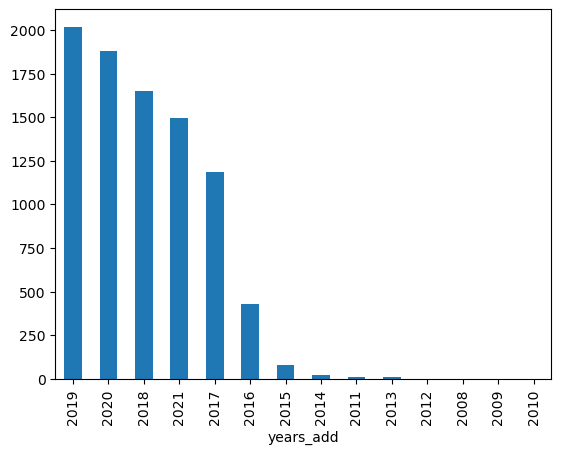

In [27]:
yearly_content.plot(kind='bar')

#### MOM Analysis

In [28]:
df['monthly_name'] = df.date_added.dt.strftime('%B')

In [29]:
MOM = df.groupby('monthly_name')['show_id'].count().sort_values(ascending=False)
MOM

monthly_name
July         827
December     813
September    770
April        764
October      760
August       755
March        742
January      738
June         728
November     705
May          632
February     563
Name: show_id, dtype: int64

Insight = In the month **July and December** the highest show has been added
          and In the month **Feb and May** the lowest show has been added

#### Top Content Created Director and Cast

In [30]:
df.nunique()   ### No. of Unique values in all the column wise 

show_id           8797
type                 2
title             8794
director          4529
cast              7683
country            749
date_added        1714
release_year        74
rating              17
duration           220
listed_in          513
description       8765
duration_value     210
duration_unit        3
years_add           14
monthly_name        12
dtype: int64

In [31]:
### Directors

In [32]:
dir = df.pivot_table(index='director',columns = 'type',values='show_id',aggfunc='count',sort=True,fill_value=0,margins=True)
dir.sort_values(by = 'All',ascending=False,inplace=True)
dir.drop('All',inplace=True)
dir.head(10)
 

type,Movie,TV Show,All
director,,,
Unknown,188,2436,2624
Rajiv Chilaka,19,0,19
"Raúl Campos, Jan Suter",18,0,18
Suhas Kadav,16,0,16
Marcus Raboy,15,1,16
Jay Karas,14,0,14
Cathy Garcia-Molina,13,0,13
Martin Scorsese,12,0,12
Jay Chapman,12,0,12


Insight= **Rajiv Chilaka and Raul Campos,Jan Suter** is the Directors who created maximum content.

In [33]:
#### Cast who worked maximum times in Movie and TV-shows.


In [34]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit,years_add,monthly_name
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min,2021,September


In [35]:
cast_df = df[['show_id', 'cast']].copy()
cast_df['cast'] = cast_df['cast'].str.split(', ')
cast_df = cast_df.explode('cast')

In [36]:
cast_dist = cast_df.groupby('cast')['show_id'].count().sort_values(ascending=False)
cast_dist.head(20)

cast
Unknown              825
Anupam Kher           43
Shah Rukh Khan        35
Julie Tejwani         33
Takahiro Sakurai      32
Naseeruddin Shah      32
Rupa Bhimani          31
Akshay Kumar          30
Om Puri               30
Yuki Kaji             29
Paresh Rawal          28
Amitabh Bachchan      28
Boman Irani           27
Vincent Tong          26
Rajesh Kava           26
Kareena Kapoor        25
Andrea Libman         25
John Cleese           24
Samuel L. Jackson     24
Jigna Bhardwaj        23
Name: show_id, dtype: int64

#### Coutry wise Analysis

In [37]:
p=df.pivot_table(index='country',columns='type',values='show_id',aggfunc='count').sort_values(by=['Movie','TV Show'],ascending=False)
p.head(10)
### Top 10 countries on the basis of type and count of content it uploaded.

type,Movie,TV Show
country,,
United States,2058.0,754.0
India,893.0,79.0
Unknown,440.0,390.0
United Kingdom,206.0,212.0
Canada,122.0,59.0
Spain,97.0,48.0
Egypt,92.0,14.0
Nigeria,86.0,9.0
Indonesia,77.0,2.0


Insight -- United States and India are the Top Countries through which highest number of content has been added.

In [38]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit,years_add,monthly_name
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min,2021,September


##### Rating wise Distribution

In [39]:
df.pivot_table(index='rating',columns='type',values='show_id',aggfunc='count',margins=True,fill_value=0)

type,Movie,TV Show,All
rating,,,
66 min,1,0,1
74 min,1,0,1
84 min,1,0,1
G,41,0,41
NC-17,3,0,3
NR,75,4,79
PG,287,0,287
PG-13,490,0,490
R,797,2,799


In [40]:
df.loc[df.rating == '66 min'].index
### Note - .index attribute is used for finding index value. 

Index([5813], dtype='int64')

In [41]:
misplaced_index = df.loc[df.rating.str.contains('min')].index

In [42]:
misplaced_index

Index([5541, 5794, 5813], dtype='int64')

In [43]:
df.loc[misplaced_index,'duration'] = df.loc[misplaced_index,'rating'] 

In [44]:
df.loc[misplaced_index,'rating'] = 'NR'

####  Genre Analysis

In [45]:
df['genre'] = df['listed_in'].str.strip().str.split(',')
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit,years_add,monthly_name,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min,2021,September,[Documentaries]


In [46]:
df_genres = df.explode('genre')

In [47]:
df_genres.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit,years_add,monthly_name,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min,2021,September,Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons,2021,September,International TV Shows
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons,2021,September,TV Dramas
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons,2021,September,TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season,2021,September,Crime TV Shows


In [48]:
genre_count = pd.DataFrame(df_genres.groupby('genre')['show_id'].count())
genre_count.sort_values(by='show_id',ascending=False)


,show_id
genre,
International Movies,2624
Dramas,1600
Comedies,1210
Action & Adventure,859
Documentaries,829
...,...
Romantic Movies,3
Spanish-Language TV Shows,2
LGBTQ Movies,1


#### Gap Analysis 
* Through the Gap analysis we analyze that netflix focus on the new content, vintage, or old content 

In [49]:
df['gap_year'] = (df.date_added.dt.year) - (df.release_year)  ## Create the gap year column 


In [50]:
gap_yearss = df.gap_year.sort_values(ascending=False).reset_index(drop=True)
gap_yearss

0       93
1       76
2       75
3       75
4       74
        ..
8792    -1
8793    -1
8794    -1
8795    -2
8796    -3
Name: gap_year, Length: 8797, dtype: int64

In [51]:
## Gap year value can't be negative so we need to replace the negative value with the 0.

In [52]:
df.loc[df.gap_year < 0,'gap_year'] = 0 ## replace the negative value with the 0.

In [53]:
### Now create the bins 
bins_ = [-1,1,5,20,50,100] 
label_ = ['New Release','Recent TV and Cinemas','Vintage','Classic','Old_favrt']
df['gap_year_bins'] =pd.cut(df['gap_year'],bins= bins_,labels=label_)


In [54]:
df.groupby('gap_year_bins',observed=False)['show_id'].count()

gap_year_bins
New Release              4840
Recent TV and Cinemas    1833
Vintage                  1624
Classic                   450
Old_favrt                  50
Name: show_id, dtype: int64

Recent TV and Cinemas - Recently release ( 2 - 5 ) years
Vintage - Movies from the previous decade (6 - 20) years
Classic - Old favourite or 90s 
Old_favrt - Black and white movies

**Insinght** -- Netflix focused on the New Released content.

In [55]:
df.pivot_table(index='gap_year_bins',columns='years_add',values ='show_id',aggfunc='count',margins=True,observed=False)

years_add,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,All
gap_year_bins,,,,,,,,,,,,,,,
New Release,1,1,0,1,2,9,20,67,281,710,904,1041,1042,761,4840
Recent TV and Cinemas,1,1,0,0,1,1,1,8,80,308,372,435,363,262,1833
Vintage,0,0,0,3,0,1,1,6,57,115,302,410,371,358,1624
Classic,0,0,1,9,0,0,2,1,11,37,70,114,94,111,450
Old_favrt,0,0,0,0,0,0,0,0,0,18,1,16,9,6,50
All,2,2,1,13,3,11,24,82,429,1188,1649,2016,1879,1498,8797


#### Content Strategy analysis 

In [56]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit,years_add,monthly_name,genre,gap_year,gap_year_bins
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min,2021,September,[Documentaries],1,New Release


In [57]:
movie_records = df[df.type=='Movie']


In [58]:
duration_by_year = movie_records.groupby('years_add')['duration_value'].mean()
print(duration_by_year)

years_add
2008     81.000000
2009     66.500000
2010     84.000000
2011     93.461538
2012     62.000000
2013     83.500000
2014     77.000000
2015     83.571429
2016     83.664032
2017     95.673421
2018    101.739693
2019     99.923455
2020    101.585670
2021    102.839879
Name: duration_value, dtype: float64


In [59]:
### TV show Longevity

In [60]:
tv_shows = df[df.type == 'TV Show']
tv_shows.groupby(['duration_value','duration_unit'])['show_id'].count()

duration_value  duration_unit
1               Season           1793
2               Seasons           421
3               Seasons           198
4               Seasons            94
5               Seasons            64
6               Seasons            33
7               Seasons            23
8               Seasons            17
9               Seasons             9
10              Seasons             6
11              Seasons             1
12              Seasons             2
13              Seasons             2
15              Seasons             2
17              Seasons             1
Name: show_id, dtype: int64

In [61]:
tv_shows_2021 = df[(df.years_add == 2021) & (df.type == 'TV Show')]

In [62]:
tv_shows_2021.groupby(['duration_value','duration_unit'])['show_id'].count()

duration_value  duration_unit
1               Season           294
2               Seasons           98
3               Seasons           50
4               Seasons           25
5               Seasons           16
6               Seasons           10
7               Seasons            6
8               Seasons            1
9               Seasons            2
10              Seasons            1
13              Seasons            1
17              Seasons            1
Name: show_id, dtype: int64

#### Export the dataframes into the CSV

In [71]:
df.to_csv("D:/Himanshu Projects/Netflix Project/netflix_main.csv",index=False)

In [72]:
df_genres[['show_id','genre']].to_csv("D:/Himanshu Projects/Netflix Project/netflix_genre.csv",index=False)

In [73]:
cast_df[['show_id','cast']].to_csv("D:/Himanshu Projects/Netflix Project/netflix_cast.csv",index=False)